# F1 · Financing a compute prepayment

A supplier offers a discount for paying a year of compute rental upfront. Is the discount large enough to cover the cost of borrowing, and how much cash must the business provide before customers pay?

Our business is a **capacity reseller**: it rents GPU computing capacity and sells access to customers. GPUs are processors used for demanding computing tasks. Renting their capacity does not give the reseller ownership of the equipment.

We compare three choices: pay the supplier each month, pay early with our own money, or pay early with some borrowed money. Customers get the same service and pay us on the same dates in all three choices. Paying early replaces the monthly supplier bills. We do not pay both.

The example uses **hypothetical** prices and loan terms. Real services can offer monthly or early payment, as [AWS's payment options](https://docs.aws.amazon.com/AWSEC2/latest/UserGuide/ec2-reserved-instances.html) show. These prices and loan terms are ours, not AWS offers.

Read Notebooks 1–2 first. Allow 10–15 minutes. The saved results can be read without running code. To use the code, follow the project README's setup steps.

In [1]:
# Install the teaching package from GitHub when running in Google Colab.
# Local Jupyter uses the repository's existing environment.
import subprocess
import sys

if "google.colab" in sys.modules:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--quiet",
            "liquid-compute[colab] @ git+https://github.com/zach189/education.git@main",
        ]
    )
    from google.colab import output

    output.enable_custom_widget_manager()

In [2]:
from liquid_compute import compute_monthly_economics

# HYPOTHETICAL inputs, not market quotes. Fractions: 0.08 means 8%.
gpu_count = 10
hours_per_month = 720
utilization_fraction = 0.75
customer_usd_per_gpu_hour = 4.0
rental_usd_per_gpu_hour = 2.0
service_months = 12
customer_payment_lag_months = 1
prepayment_discount_fraction = 0.08
financed_fraction = 0.80
nominal_annual_interest_rate = 0.12
loan_term_months = 12
origination_fee_fraction = 0.02
annual_discount_rate = 0.12  # Effective annual PV rate; distinct from loan interest.

operating = compute_monthly_economics(
    gpu_count=gpu_count,
    hours_per_month=hours_per_month,
    rental_usd_per_gpu_hour=rental_usd_per_gpu_hour,
    customer_usd_per_gpu_hour=customer_usd_per_gpu_hour,
    utilization_fraction=utilization_fraction,
)
monthly_revenue_usd = operating.revenue_usd
monthly_rental_usd = operating.rental_expense_usd
print(f"Monthly revenue: USD {monthly_revenue_usd:,.2f}")
print(f"Monthly base rental expense: USD {monthly_rental_usd:,.2f}")

Monthly revenue: USD 21,600.00
Monthly base rental expense: USD 14,400.00


### Set out the payment dates

Cash becomes available when a payment arrives, which can be later than the service or invoice date. The example uses the following payment schedule:

| Money movement | When it happens |
|---|---|
| Pay the supplier monthly | Start of each month, for 12 months |
| Or pay the supplier all at once | Start of the first month |
| Receive the loan and pay its fee | Start of the first month |
| Repay the loan | End of each month, for 12 months |
| Receive customer money | One month after each service month ends |

For example, customers pay for January at the end of February. The last customer payment comes in month 13.

“Time zero” is the start of the schedule. Receipts and payments at the same point are netted together; this monthly model does not track their order within a day.

First find the early-payment price. Then find how much we borrow and the loan fee. The fee is paid from cash; we do not borrow extra to cover it.

In [3]:
undiscounted_supplier_usd = service_months * monthly_rental_usd
supplier_savings_usd = undiscounted_supplier_usd * prepayment_discount_fraction
prepayment_usd = undiscounted_supplier_usd - supplier_savings_usd
principal_usd = financed_fraction * prepayment_usd
fee_usd = origination_fee_fraction * principal_usd
initial_own_cash_usd = prepayment_usd + fee_usd - principal_usd
print(f"Supplier discount saves USD {supplier_savings_usd:,.2f}")
print(f"Prepayment: USD {prepayment_usd:,.2f}; loan: USD {principal_usd:,.2f}")
print(f"Fee: USD {fee_usd:,.2f}; initial own cash: USD {initial_own_cash_usd:,.2f}")

Supplier discount saves USD 13,824.00
Prepayment: USD 158,976.00; loan: USD 127,180.80
Fee: USD 2,543.62; initial own cash: USD 34,338.82


### Separate principal from interest

Each loan payment has two parts: **principal**, which repays the amount borrowed, and **interest**, the lender’s charge on the remaining debt. A [loan payment schedule](https://www.consumerfinance.gov/ask-cfpb/what-is-amortization-and-how-could-it-affect-my-auto-loan-en-771/) shows both parts.

Our monthly interest rate is the stated yearly loan rate divided by 12. There is also a fee. [Interest and fees are different costs](https://www.consumerfinance.gov/ask-cfpb/what-is-the-difference-between-a-loan-interest-rate-and-the-apr-en-733/); the quoted interest rate does not include the fee in an all-in annual percentage rate (APR).

Each month, interest is charged on the debt still left. The rest of the payment makes that debt smaller. The code works out the first two months before asking the shared calculator for the whole schedule.

Borrowing money is not a sale. Paying back principal is not a second computer rental bill.

In [4]:
monthly_loan_rate = nominal_annual_interest_rate / 12
monthly_payment_usd = (
    principal_usd / loan_term_months
    if monthly_loan_rate == 0
    else principal_usd
    * monthly_loan_rate
    / (1 - (1 + monthly_loan_rate) ** (-loan_term_months))
)
opening_debt_usd = principal_usd
for month in (1, 2):
    interest_usd = opening_debt_usd * monthly_loan_rate
    principal_repayment_usd = monthly_payment_usd - interest_usd
    closing_debt_usd = opening_debt_usd - principal_repayment_usd
    print(
        f"Month {month}: payment {monthly_payment_usd:,.2f}, interest {interest_usd:,.2f}, "
        f"principal {principal_repayment_usd:,.2f}, closing debt {closing_debt_usd:,.2f} USD"
    )
    opening_debt_usd = closing_debt_usd

Month 1: payment 11,299.86, interest 1,271.81, principal 10,028.05, closing debt 117,152.75 USD
Month 2: payment 11,299.86, interest 1,171.53, principal 10,128.33, closing debt 107,024.42 USD


### Follow the remaining loan balance

The monthly payment stays constant, but its composition changes. As outstanding principal falls, the interest charge falls too, leaving more of each payment to repay principal.

The loan is drawn at the start, with the first repayment one month later. The scheduled payments fully repay it; no additional final payment is assumed.

The calculation retains full precision and rounds only the displayed amounts.

In [5]:
from liquid_compute.education import show_loan_schedule
from liquid_compute.financing import build_amortizing_loan_schedule

loan = build_amortizing_loan_schedule(
    principal_usd=principal_usd,
    nominal_annual_interest_rate=nominal_annual_interest_rate,
    loan_term_months=loan_term_months,
    origination_fee_fraction=origination_fee_fraction,
)
show_loan_schedule(loan)

All amounts in USD; payments are positive.

| Month t | Opening debt | Draw | Interest | Principal | Fee | Closing debt |
|---:|---:|---:|---:|---:|---:|---:|
| 0 | 0.00 | 127,180.80 | 0.00 | 0.00 | 2,543.62 | 127,180.80 |
| 1 | 127,180.80 | 0.00 | 1,271.81 | 10,028.05 | 0.00 | 117,152.75 |
| 2 | 117,152.75 | 0.00 | 1,171.53 | 10,128.33 | 0.00 | 107,024.42 |
| 3 | 107,024.42 | 0.00 | 1,070.24 | 10,229.62 | 0.00 | 96,794.80 |
| 4 | 96,794.80 | 0.00 | 967.95 | 10,331.91 | 0.00 | 86,462.89 |
| 5 | 86,462.89 | 0.00 | 864.63 | 10,435.23 | 0.00 | 76,027.66 |
| 6 | 76,027.66 | 0.00 | 760.28 | 10,539.58 | 0.00 | 65,488.07 |
| 7 | 65,488.07 | 0.00 | 654.88 | 10,644.98 | 0.00 | 54,843.09 |
| 8 | 54,843.09 | 0.00 | 548.43 | 10,751.43 | 0.00 | 44,091.66 |
| 9 | 44,091.66 | 0.00 | 440.92 | 10,858.94 | 0.00 | 33,232.72 |
| 10 | 33,232.72 | 0.00 | 332.33 | 10,967.53 | 0.00 | 22,265.19 |
| 11 | 22,265.19 | 0.00 | 222.65 | 11,077.21 | 0.00 | 11,187.98 |
| 12 | 11,187.98 | 0.00 | 111.88 | 11,187.98 | 0.00 | 0.00 |


### Ask three separate questions

**How much do we pay altogether?** Add the supplier price, interest and fees. Do not add borrowed principal again: it already paid part of the supplier price.

**What are those payments worth today?** This is called **present value**, or **PV**. Money paid later is treated differently from money paid now. We use one chosen comparison rate for every choice. That rate is a comparison rule, not another bill.

For this comparison, money going out includes supplier bills, interest, principal and fees. Subtract the loan money coming in. Customer payments are the same in each choice, so we leave them out of this cost comparison.

**How much money must be ready?** Now include customers' payments too. Follow the cash balance from the start to the last receipt. The deepest dip below zero tells us the extra cash needed. We call this the **cash buffer**. A lower present-value cost does not remove the need to fund payments as they fall due.

Borrowed prepayment, cumulative USD at t=0,1,2: -34,338.82; -45,638.68; -35,338.54


Amounts in USD; PV uses 12.00% effective annually.

| Measure | Monthly | Own-cash prepayment | Borrowed prepayment |
|---|---:|---:|---:|
| Total supplier cost | 172,800.00 | 158,976.00 | 158,976.00 |
| Total interest and fees | 0.00 | 0.00 | 10,961.14 |
| Total supplier and financing cost | 172,800.00 | 158,976.00 | 169,937.14 |
| PV of net procurement-and-financing outflows | 164,140.69 | 158,976.00 | 161,931.37 |
| Initial own cash (t=0) | 14,400.00 | 158,976.00 | 34,338.82 |
| Required initial cash buffer (whole schedule) | 28,800.00 | 158,976.00 | 45,638.68 |


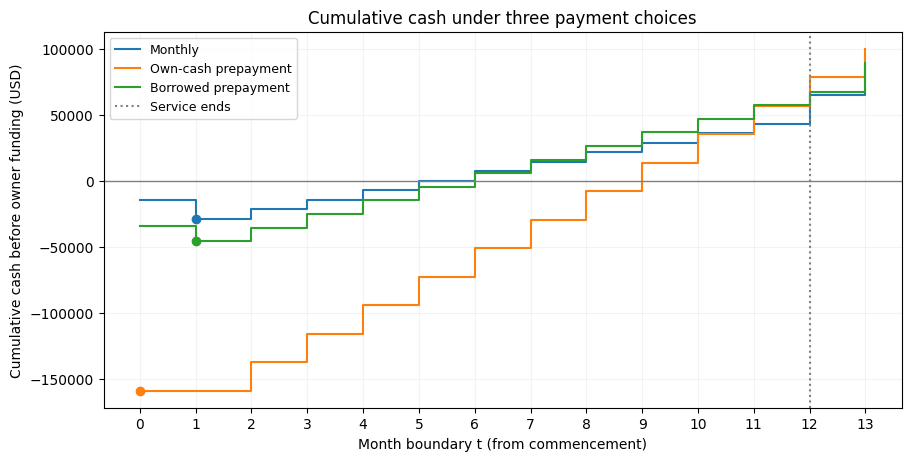

In [6]:
from liquid_compute.education import plot_financing_cash, show_financing_comparison
from liquid_compute.financing import compare_prepayment_financing

# Direct funding arithmetic: no customer receipt at t=0 or t=1.
cash_t0 = principal_usd - prepayment_usd - fee_usd
cash_t1 = cash_t0 - monthly_payment_usd
cash_t2 = cash_t1 + monthly_revenue_usd - monthly_payment_usd
print(
    f"Borrowed prepayment, cumulative USD at t=0,1,2: "
    f"{cash_t0:,.2f}; {cash_t1:,.2f}; {cash_t2:,.2f}"
)


financing_inputs = dict(
    monthly_revenue_usd=monthly_revenue_usd,
    base_monthly_rental_expense_usd=monthly_rental_usd,
    service_months=service_months,
    customer_payment_lag_months=customer_payment_lag_months,
    prepayment_discount_fraction=prepayment_discount_fraction,
    financed_fraction=financed_fraction,
    nominal_annual_interest_rate=nominal_annual_interest_rate,
    loan_term_months=loan_term_months,
    origination_fee_fraction=origination_fee_fraction,
)
alternatives = compare_prepayment_financing(**financing_inputs)
show_financing_comparison(alternatives, annual_discount_rate=annual_discount_rate)

plot_financing_cash(alternatives, service_months=service_months);

### Distinguish the initial payment from total funding needs

With borrowing, we need USD 34,338.82 of our own cash at the start. But a loan payment comes before customer money arrives. To get through the whole schedule, we need USD 45,638.68 ready.

The chart tracks the running cash balance for each choice. Each dot marks its lowest point. The cash buffer is the amount of initial funding needed to keep that balance nonnegative throughout the schedule.

The controls below make a separate comparison. They do not change the later examples. Enter `0.08` for 8%. If controls do not work, the input cells can be edited instead.

In [7]:
from liquid_compute.education import explore_prepayment_financing

explore_prepayment_financing(
    financing_inputs, annual_discount_rate=annual_discount_rate
);

### Experiment 1 · A smaller saving

Keep everything else the same. Let the supplier's price cut fall from 8% to 4%.

The smaller discount increases the upfront supplier payment. Because the financed share is unchanged, the loan amount and its fee also increase.

Will the saving still cover the cost of borrowing?

In [8]:
example = dict(
    monthly_revenue_usd=21600,
    base_monthly_rental_expense_usd=14400,
    service_months=12,
    customer_payment_lag_months=1,
    prepayment_discount_fraction=0.08,
    financed_fraction=0.8,
    nominal_annual_interest_rate=0.12,
    loan_term_months=12,
    origination_fee_fraction=0.02,
)
base = compare_prepayment_financing(**example)
smaller_discount = compare_prepayment_financing(
    **(example | {"prepayment_discount_fraction": 0.04})
)
show_financing_comparison(
    {
        "Monthly": base["Monthly"],
        "Borrowed, 8% discount": base["Borrowed prepayment"],
        "Borrowed, 4% discount": smaller_discount["Borrowed prepayment"],
    },
    annual_discount_rate=0.12,
)

Amounts in USD; PV uses 12.00% effective annually.

| Measure | Monthly | Borrowed, 8% discount | Borrowed, 4% discount |
|---|---:|---:|---:|
| Total supplier cost | 172,800.00 | 158,976.00 | 165,888.00 |
| Total interest and fees | 0.00 | 10,961.14 | 11,437.71 |
| Total supplier and financing cost | 172,800.00 | 169,937.14 | 177,325.71 |
| PV of net procurement-and-financing outflows | 164,140.69 | 161,931.37 | 168,971.86 |
| Initial own cash (t=0) | 14,400.00 | 34,338.82 | 35,831.81 |
| Required initial cash buffer (whole schedule) | 28,800.00 | 45,638.68 | 47,622.97 |


The smaller price cut saves USD 6,912. Interest and fees cost more than that. Borrowing to pay early now costs more than buying monthly.

Assess the supplier discount together with the interest and fees needed to finance it.

### Experiment 2 · A more costly loan

Put the supplier saving back at 8%. Raise the yearly loan rate from 12% to 24%.

Keep the PV comparison rate at 12%. We are changing the lender's bill, not the rule used to compare payment dates.

In [9]:
expensive_loan = compare_prepayment_financing(
    **(example | {"nominal_annual_interest_rate": 0.24})
)
show_financing_comparison(
    {
        "Monthly": base["Monthly"],
        "Borrowed, 12% loan": base["Borrowed prepayment"],
        "Borrowed, 24% loan": expensive_loan["Borrowed prepayment"],
    },
    annual_discount_rate=0.12,
)

Amounts in USD; PV uses 12.00% effective annually.

| Measure | Monthly | Borrowed, 12% loan | Borrowed, 24% loan |
|---|---:|---:|---:|
| Total supplier cost | 172,800.00 | 158,976.00 | 158,976.00 |
| Total interest and fees | 0.00 | 10,961.14 | 19,676.80 |
| Total supplier and financing cost | 172,800.00 | 169,937.14 | 178,652.80 |
| PV of net procurement-and-financing outflows | 164,140.69 | 161,931.37 | 170,132.45 |
| Initial own cash (t=0) | 14,400.00 | 34,338.82 | 34,338.82 |
| Required initial cash buffer (whole schedule) | 28,800.00 | 45,638.68 | 46,364.98 |


The bigger loan rate makes each payment larger. We also need a bigger cash buffer. The supplier price and customer payments stay the same.

At 24%, interest and fees cost more than the 8% supplier saving.

### Experiment 3 · Borrow more of the price

Compare borrowing none, 80%, and all of the supplier price. Does borrowing all of it mean we never need our own money?

Then try borrowing all of it with no loan fee. This is a separate hypothetical case.

In [10]:
financing_cases = {
    f"{fraction:.0%} financed": compare_prepayment_financing(
        **(example | {"financed_fraction": fraction})
    )["Borrowed prepayment"]
    for fraction in (0.0, 0.8, 1.0)
}
financing_cases["100%, no fee"] = compare_prepayment_financing(
    **(example | {"financed_fraction": 1.0, "origination_fee_fraction": 0.0})
)["Borrowed prepayment"]
show_financing_comparison(financing_cases, annual_discount_rate=0.12)

Amounts in USD; PV uses 12.00% effective annually.

| Measure | 0% financed | 80% financed | 100% financed | 100%, no fee |
|---|---:|---:|---:|---:|
| Total supplier cost | 158,976.00 | 158,976.00 | 158,976.00 | 158,976.00 |
| Total interest and fees | 0.00 | 10,961.14 | 13,701.42 | 10,521.90 |
| Total supplier and financing cost | 158,976.00 | 169,937.14 | 172,677.42 | 169,497.90 |
| PV of net procurement-and-financing outflows | 158,976.00 | 161,931.37 | 162,670.21 | 159,490.69 |
| Initial own cash (t=0) | 158,976.00 | 34,338.82 | 3,179.52 | 0.00 |
| Required initial cash buffer (whole schedule) | 158,976.00 | 45,638.68 | 17,304.35 | 14,124.83 |


More borrowing means less of our money is needed at the start. It also brings more interest and fees.

Even borrowing the whole price **with no fee** leaves a problem: USD 14,124.83 is due before customer payments begin. Starting with no cash payment does not mean the whole plan needs no cash.

### How big must the supplier saving be?

Find the **break-even discount**: the supplier price reduction at which prepayment and monthly purchasing have equal costs. Calculate it separately for total dollars and present value.

The code first works through the arithmetic. Then it checks the result with the shared calculator. Bigger early-payment amounts create proportionally bigger loans, interest and fees in this example.

In [11]:
from liquid_compute.discounting import present_value_usd
from liquid_compute.financing import (
    financed_prepayment_break_even_discount_fraction,
    net_procurement_outflows_usd,
)

borrowed = alternatives["Borrowed prepayment"]
interest_and_fees_usd = loan_term_months * monthly_payment_usd - principal_usd + fee_usd
k_cost = 1 + interest_and_fees_usd / prepayment_usd
k_pv = (
    present_value_usd(
        net_procurement_outflows_usd(borrowed),
        annual_discount_rate=annual_discount_rate,
    )
    / prepayment_usd
)
monthly_pv = present_value_usd(
    [monthly_rental_usd] * service_months, annual_discount_rate=annual_discount_rate
)
print(f"Direct undiscounted threshold: {1 - 1 / k_cost:.4%}")
print(f"Direct PV threshold: {1 - monthly_pv / (undiscounted_supplier_usd * k_pv):.4%}")
for measure in ("undiscounted", "present_value"):
    threshold = financed_prepayment_break_even_discount_fraction(
        service_months=service_months,
        loan_term_months=loan_term_months,
        financed_fraction=financed_fraction,
        nominal_annual_interest_rate=nominal_annual_interest_rate,
        origination_fee_fraction=origination_fee_fraction,
        cost_measure=measure,
        annual_discount_rate=annual_discount_rate,
    )
    print(f"Shared {measure} threshold: {threshold:.4%}")
    if 0 <= threshold < 1:
        matching = compare_prepayment_financing(
            **(financing_inputs | {"prepayment_discount_fraction": threshold})
        )
        comparison_rate = 0 if measure == "undiscounted" else annual_discount_rate
        for name in ("Monthly", "Borrowed prepayment"):
            value = present_value_usd(
                net_procurement_outflows_usd(matching[name]),
                annual_discount_rate=comparison_rate,
            )
            print(f"  {name}: USD {value:,.2f}")
    else:
        print(
            "Threshold lies outside the modeled supplier discount range; it is not clipped."
        )

Direct undiscounted threshold: 6.4501%
Direct PV threshold: 6.7448%
Shared undiscounted threshold: 6.4501%
  Monthly: USD 172,800.00
  Borrowed prepayment: USD 172,800.00
Shared present_value threshold: 6.7448%
  Monthly: USD 164,140.69
  Borrowed prepayment: USD 164,140.69


The two break-even discounts are **6.4501% for total dollars** and **6.7448% for PV**. The assumed 8% discount exceeds both, so prepayment is cheaper on both measures in this example. The cash buffer is still required.

These answers use our chosen terms. They are not a real offer. A negative break-even discount would mean no positive price cut is needed for that particular comparison.

### Reconcile the cash movements

The table below shows the supplier purchase, the loan arriving, and each repayment. Debt ends in month 12. Customer money keeps arriving through month 13.

This table follows cash. The rental cost still belongs to the months when service is used, as in Notebook 2.

In [12]:
from liquid_compute.education import show_financing_schedule

show_financing_schedule(alternatives["Borrowed prepayment"])

Cash movements (USD), before owner funding.

| Month t | Supplier | Customer | Loan draw | Interest | Principal | Fee | Net cash |
|---:|---:|---:|---:|---:|---:|---:|---:|
| 0 | 158,976.00 | 0.00 | 127,180.80 | 0.00 | 0.00 | 2,543.62 | -34,338.82 |
| 1 | 0.00 | 0.00 | 0.00 | 1,271.81 | 10,028.05 | 0.00 | -11,299.86 |
| 2 | 0.00 | 21,600.00 | 0.00 | 1,171.53 | 10,128.33 | 0.00 | 10,300.14 |
| 3 | 0.00 | 21,600.00 | 0.00 | 1,070.24 | 10,229.62 | 0.00 | 10,300.14 |
| 4 | 0.00 | 21,600.00 | 0.00 | 967.95 | 10,331.91 | 0.00 | 10,300.14 |
| 5 | 0.00 | 21,600.00 | 0.00 | 864.63 | 10,435.23 | 0.00 | 10,300.14 |
| 6 | 0.00 | 21,600.00 | 0.00 | 760.28 | 10,539.58 | 0.00 | 10,300.14 |
| 7 | 0.00 | 21,600.00 | 0.00 | 654.88 | 10,644.98 | 0.00 | 10,300.14 |
| 8 | 0.00 | 21,600.00 | 0.00 | 548.43 | 10,751.43 | 0.00 | 10,300.14 |
| 9 | 0.00 | 21,600.00 | 0.00 | 440.92 | 10,858.94 | 0.00 | 10,300.14 |
| 10 | 0.00 | 21,600.00 | 0.00 | 332.33 | 10,967.53 | 0.00 | 10,300.14 |
| 11 | 0.00 | 21,600.00 | 0.00 | 222.65 | 11,077.21 | 0.00 | 10,300.14 |
| 12 | 0.00 | 21,600.00 | 0.00 | 111.88 | 11,187.98 | 0.00 | 10,300.14 |
| 13 | 0.00 | 21,600.00 | 0.00 | 0.00 | 0.00 | 0.00 | 21,600.00 |

Balances (USD). Negative cash is a funding need, not an assumed overdraft.

| Month t | Cumulative cash | Outstanding debt |
|---:|---:|---:|
| 0 | -34,338.82 | 127,180.80 |
| 1 | -45,638.68 | 117,152.75 |
| 2 | -35,338.54 | 107,024.42 |
| 3 | -25,038.40 | 96,794.80 |
| 4 | -14,738.26 | 86,462.89 |
| 5 | -4,438.12 | 76,027.66 |
| 6 | 5,862.02 | 65,488.07 |
| 7 | 16,162.16 | 54,843.09 |
| 8 | 26,462.30 | 44,091.66 |
| 9 | 36,762.44 | 33,232.72 |
| 10 | 47,062.58 | 22,265.19 |
| 11 | 57,362.72 | 11,187.98 |
| 12 | 67,662.86 | 0.00 |
| 13 | 89,262.86 | 0.00 |


### Implications for the financing decision

Prepayment is attractive when the supplier savings cover financing costs and the business can fund the interval before customer receipts arrive.

Compare total cost, present value and the cash required before receipts arrive. Each answers a different financing question.

This example leaves out missed payments, taxes, extra business costs and many real loan rules. We do not assume the lender can take the rented computers: we do not own them. Using our own money also means we cannot use it elsewhere; the chosen PV rate helps us compare that trade-off.

The linked sources explain general ideas. They do not promise that a lender will offer this loan.

**Next: F2.** We switch to a project buying equipment. It needs a short loan to fund an equipment deposit before a customer prepayment arrives. Paying for setup and running the equipment comes later.